# 04 - Backtest

Backtest the moving-average strategy against the buy-and-hold benchmark using the signals generated in the previous notebook.


## Setup

Rebuild the full pipeline: prices -> daily returns -> moving averages -> signal/position -> backtest.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd().parent / "src"))
import data
import performance
import signals
import backtest

prices = data.load_prices()
returns = performance.daily_returns(prices)
sig = signals.generate_signals(signals.add_moving_averages(returns))
bt = backtest.run_backtest(sig)
bt = backtest.add_drawdowns(bt)


## How the backtest works

`StrategyReturn` on day *t* is simply `Position(t) * Return(t)`. No extra shifting is needed here -- `Position` was already lagged by one day back in `signals.generate_signals()`, so multiplying it by the same day's return correctly means "the return earned by a position that was decided using yesterday's close." This is a **vectorized backtest**: fast and simple, but it assumes we can always trade at the closing price with no transaction costs or slippage -- a simplification we'll revisit in a later phase.


In [2]:
bt[bt["Ticker"] == "SPY"][["Date", "Close", "Position", "Return", "StrategyReturn"]].tail()


,Date,Close,Position,Return,StrategyReturn
20985,2026-09-04,770.190002,1.0,-0.003854,-0.003854
20986,2026-09-08,765.960022,1.0,-0.005492,-0.005492
20987,2026-09-09,762.400024,1.0,-0.004648,-0.004648
20988,2026-09-10,757.830017,1.0,-0.005994,-0.005994
20989,2026-09-11,764.289978,1.0,0.008524,0.008524


## Equity curves: strategy vs. buy-and-hold, all five tickers

Growth of $1 for the strategy vs. simply holding the asset the whole time.


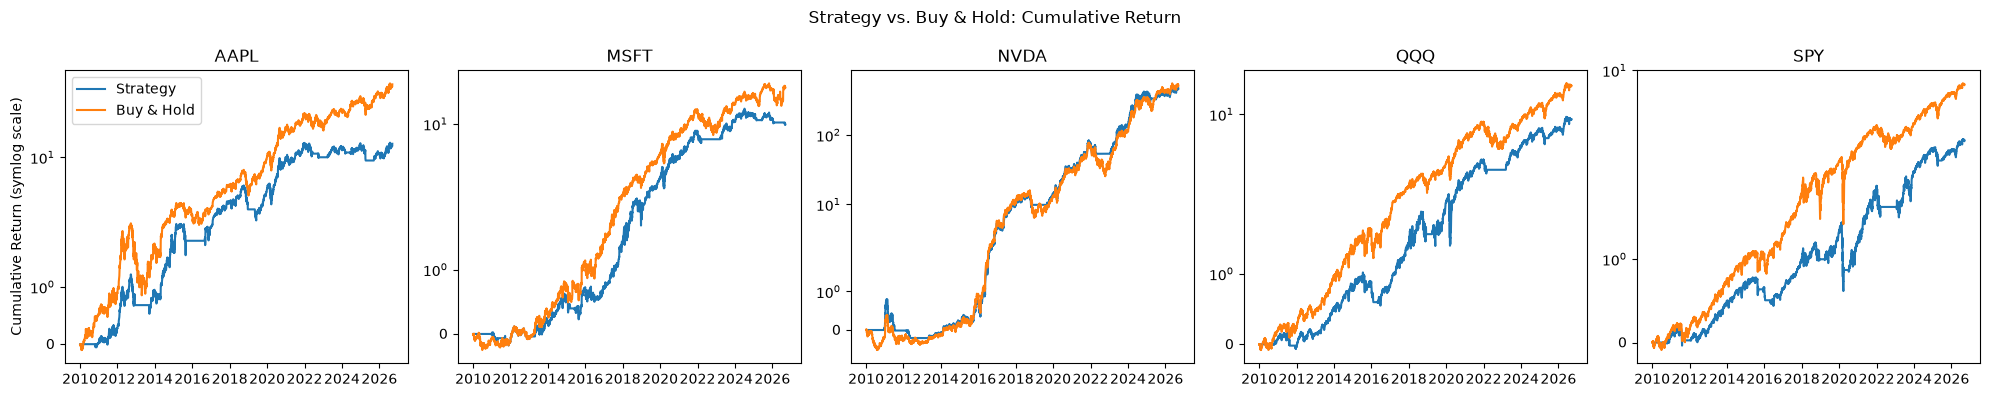

In [3]:
tickers = sorted(bt["Ticker"].unique())
fig, axes = plt.subplots(1, len(tickers), figsize=(20, 4), sharex=True)

for ax, ticker in zip(axes, tickers):
    sub = bt[bt["Ticker"] == ticker]
    ax.plot(sub["Date"], sub["StrategyCumReturn"], label="Strategy")
    ax.plot(sub["Date"], sub["BenchmarkCumReturn"], label="Buy & Hold")
    ax.set_title(ticker)
    ax.set_yscale("symlog")

axes[0].set_ylabel("Cumulative Return (symlog scale)")
axes[0].legend()
fig.suptitle("Strategy vs. Buy & Hold: Cumulative Return")
plt.tight_layout()
plt.show()


## Drawdown: strategy vs. buy-and-hold (SPY)

Drawdown measures how far the equity curve has fallen from its running peak -- a direct view of downside pain, which raw cumulative return doesn't show.


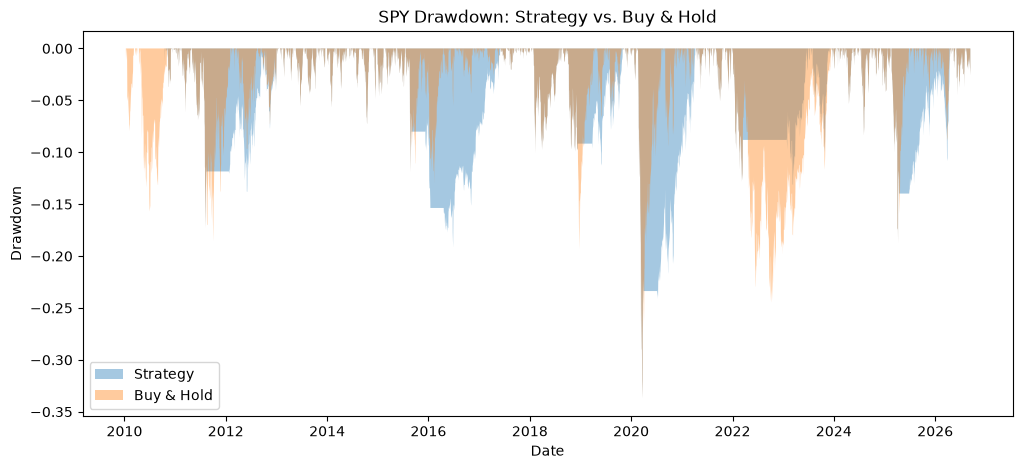

In [4]:
spy = bt[bt["Ticker"] == "SPY"]

fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(spy["Date"], spy["StrategyDrawdown"], 0, alpha=0.4, label="Strategy")
ax.fill_between(spy["Date"], spy["BenchmarkDrawdown"], 0, alpha=0.4, label="Buy & Hold")
ax.set_title("SPY Drawdown: Strategy vs. Buy & Hold")
ax.set_xlabel("Date")
ax.set_ylabel("Drawdown")
ax.legend()
plt.show()


## Summary: final cumulative return and max drawdown


In [5]:
summary = bt.groupby("Ticker").agg(
    StrategyCumReturn=("StrategyCumReturn", "last"),
    BenchmarkCumReturn=("BenchmarkCumReturn", "last"),
    StrategyMaxDrawdown=("StrategyDrawdown", "min"),
    BenchmarkMaxDrawdown=("BenchmarkDrawdown", "min"),
)
summary


,StrategyCumReturn,BenchmarkCumReturn,StrategyMaxDrawdown,BenchmarkMaxDrawdown
Ticker,,,,
AAPL,13.531797,50.909392,-0.456128,-0.437972
MSFT,9.899137,20.563907,-0.280393,-0.371485
NVDA,465.478216,515.274884,-0.565589,-0.663351
QQQ,9.119672,16.762516,-0.285594,-0.351187
SPY,3.415138,8.036460,-0.337173,-0.337173


## Notes / Next Step

The strategy underperforms buy-and-hold on **raw** cumulative return for every ticker in this sample -- a very common, real finding for trend-following strategies over a period dominated by a strong secular bull market. Two things stand out:
- The strategy is only ever out of the market to avoid a *sustained* downtrend; it doesn't dodge sharp, fast crashes -- notice SPY's strategy and benchmark drawdowns are nearly identical, meaning the signal was already fully invested going into that particular crash and couldn't react in time.
- Being in cash part of the time means missing some of the recovery too, which compounds against the strategy over a long bull run.

Raw return isn't the whole story, though -- our research question is about **risk-adjusted** performance. A strategy with lower return but also much lower volatility/drawdown could still win on a metric like the Sharpe ratio.

**Next:** `05_performance_analysis.ipynb` -- compute CAGR, annualized volatility, Sharpe ratio, and max drawdown side by side to properly answer the research question.
